StatsBomb maps every event onto a 120 × 80 coordinate system:
|  |  | 
|  |  | 
|  |  | 


This means:
- x = 0 → your own goal line
- x = 120 → opponent’s goal line
- y = 0 → bottom touchline
- y = 80 → top touchline
And the goalposts are always at:
- Left post: (120, 36)
- Right post: (120, 44)
- Goal centre: (120, 40)
This is why your distance/angle calculations earlier worked perfectly.


In [9]:
import sys
sys.executable

'C:\\Users\\bcarr\\.conda\\envs\\football-xg\\python.exe'

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd

In [11]:
import os

_nb_file = globals().get('__vsc_ipynb_file__', '')
_notebook_dir = os.path.dirname(os.path.abspath(_nb_file)) if _nb_file else os.getcwd()
_models_dir = os.path.normpath(os.path.join(_notebook_dir, '..', 'models'))

model = joblib.load(os.path.join(_models_dir, "xgboost.pkl"))
preproc = joblib.load(os.path.join(_models_dir, "preprocessor.pkl"))

(np.float64(-0.5), np.float64(1156.5), np.float64(570.5), np.float64(-0.5))

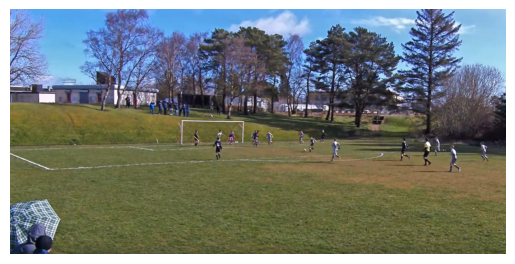

In [12]:
# Build robust path relative to this notebook, regardless of kernel CWD
_nb_file = globals().get('__vsc_ipynb_file__', '')
if _nb_file:
    _notebook_dir = os.path.dirname(os.path.abspath(_nb_file))
else:
    # Fallback: assume CWD is the notebook's directory
    _notebook_dir = os.getcwd()

_img_path = os.path.normpath(os.path.join(_notebook_dir, '..', 'images', 'shot_frame.jpg'))

img = cv2.imread(_img_path)
if img is None:
    raise FileNotFoundError(f"Could not load image.\n  Tried: {_img_path}\n  CWD: {os.getcwd()}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

In [13]:
# Enter the StatsBomb (x, y) coordinates of the shot
# x: 0 (own goal) → 120 (opponent goal), y: 0 (bottom) → 80 (top)
shot_x = float(input("Shot x coordinate (0–120): "))
shot_y = float(input("Shot y coordinate (0–80): "))

VALID_BODY_PARTS = {"Right Foot", "Left Foot", "Head", "Other"}
body_part = input("Body part (Right Foot / Left Foot / Head / Other): ").strip().title()
if body_part not in VALID_BODY_PARTS:
    raise ValueError(f"Invalid body part '{body_part}'. Must be one of: {VALID_BODY_PARTS}")

VALID_PLAY_TYPES = {"Open Play", "Free Kick", "Penalty"}
play_type = input("Play type (Open Play / Free Kick / Penalty): ").strip().title()
if play_type not in VALID_PLAY_TYPES:
    raise ValueError(f"Invalid play type '{play_type}'. Must be one of: {VALID_PLAY_TYPES}")

# --- Situational context (skipped for Penalty — fixed at zero in training data) ---
if play_type == "Penalty":
    under_pressure = False
    keeper_x, keeper_y = float("nan"), float("nan")
    nearest_defender, defender_density, defenders_between = 0.0, 0, 0
    print(f"\nShot: ({shot_x}, {shot_y})  |  {body_part}  |  {play_type}")
    print("(Keeper / defender fields are zeroed for penalties, matching training data.)")
else:
    print()
    print("Under pressure: was a defender within ~2 m of the shooter at the moment of the shot?")
    under_pressure = input("  Under pressure? (yes / no) [no]: ").strip().lower() in ("yes", "y", "1", "true")

    print()
    print("Goalkeeper position — StatsBomb 120×80 grid.")
    print("  Typical: x ≈ 118 (on goal line), y ≈ 40 (centre of goal).")
    print("  Data range:  x 26–120,  y 21–61.  Press Enter to use defaults.")
    _kx = input("  Goalkeeper x (26–120) [118]: ").strip()
    keeper_x = float(_kx) if _kx else 118.0
    _ky = input("  Goalkeeper y (21–61)  [40]:  ").strip()
    keeper_y = float(_ky) if _ky else 40.0

    print()
    print("Nearest defender distance — straight-line distance (StatsBomb units ≈ metres)")
    print("  from the shooter to the closest defending outfield player.")
    print("  Data range: 0–106.  Typical: 2–5.")
    _nd = input("  Nearest defender distance [2.3]: ").strip()
    nearest_defender = float(_nd) if _nd else 2.3

    print()
    print("Defender density — number of defending players within a ~3-unit radius")
    print("  of the shot location. Shows how crowded the shooting zone is.")
    print("  Data range: 0–8.  Typical: 0–2.")
    _dd = input("  Defender density (0–8) [1]: ").strip()
    defender_density = int(_dd) if _dd else 1

    print()
    print("Defenders between shooter and goal — count of defenders whose position")
    print("  lies between the shot location and the goal line, blocking the sightline.")
    print("  Data range: 0–10.  Typical: 0–1.")
    _db = input("  Defenders between (0–10) [0]: ").strip()
    defenders_between = int(_db) if _db else 0

    print(f"\nShot: ({shot_x}, {shot_y})  |  {body_part}  |  {play_type}  |  Under pressure: {under_pressure}")
    print(f"Keeper: ({keeper_x}, {keeper_y})  |  Nearest def: {nearest_defender}  |  Density: {defender_density}  |  Between: {defenders_between}")


Shot x coordinate (0–120):  104
Shot y coordinate (0–80):  45
Body part (Right Foot / Left Foot / Head / Other):  Left Foot
Play type (Open Play / Free Kick / Penalty):  Open Play



Under pressure: was a defender within ~2 m of the shooter at the moment of the shot?


  Under pressure? (yes / no) [no]:  no



Goalkeeper position — StatsBomb 120×80 grid.
  Typical: x ≈ 118 (on goal line), y ≈ 40 (centre of goal).
  Data range:  x 26–120,  y 21–61.  Press Enter to use defaults.


  Goalkeeper x (26–120) [118]:  118
  Goalkeeper y (21–61)  [40]:   42


...

  Defender density (0–8) [1]:  0



Defenders between shooter and goal — count of defenders whose position
  lies between the shot location and the goal line, blocking the sightline.
  Data range: 0–10.  Typical: 0–1.


  Defenders between (0–10) [0]:  1



Shot: (104.0, 45.0)  |  Left Foot  |  Open Play  |  Under pressure: False
Keeper: (118.0, 42.0)  |  Nearest def: 10.0  |  Density: 0  |  Between: 1


Shot position: (104.0, 45.0)  |  Body part: Right Foot  |  Play type: Open Play


In [14]:
distance = np.sqrt((120 - shot_x)**2 + (40 - shot_y)**2)

# Angle to goal: angle subtended by the goalposts from the shot position
post_left  = np.array([120, 36])
post_right = np.array([120, 44])
shot_pos   = np.array([shot_x, shot_y])

vec_l = post_left  - shot_pos
vec_r = post_right - shot_pos
cos_angle = np.dot(vec_l, vec_r) / (np.linalg.norm(vec_l) * np.linalg.norm(vec_r) + 1e-9)
angle = np.arccos(np.clip(cos_angle, -1, 1))

# All situational features come from the input cell above
features = {
    "shot_x": shot_x,
    "shot_y": shot_y,
    "distance": distance,
    "angle": angle,
    "nearest_defender": nearest_defender,
    "defender_density": defender_density,
    "defenders_between": defenders_between,
    "keeper_x": keeper_x,
    "keeper_y": keeper_y,
    "body_part": body_part,
    "play_type": play_type,
    "under_pressure": under_pressure,
}

print(f"Distance: {distance:.2f}  |  Angle: {np.degrees(angle):.1f}°")


Distance: 16.76  |  Angle: 25.8°


In [15]:
df = pd.DataFrame([features])
X = preproc.transform(df)
xg = model.predict_proba(X)[0, 1]
print("Predicted xG:", xg)

Predicted xG: 0.114942014


In [16]:
import pandas as pd

def predict_xg(sx, sy, bp="Right Foot", pt="Open Play",
               nearest_def=2.0, def_density=1, defs_between=0,
               kx=118.0, ky=40.0):
    dist = np.sqrt((120 - sx)**2 + (40 - sy)**2)
    vl = np.array([120, 36]) - np.array([sx, sy])
    vr = np.array([120, 44]) - np.array([sx, sy])
    cos_a = np.dot(vl, vr) / (np.linalg.norm(vl) * np.linalg.norm(vr) + 1e-9)
    ang = np.arccos(np.clip(cos_a, -1, 1))
    row = {"shot_x": sx, "shot_y": sy, "distance": dist, "angle": ang,
           "nearest_defender": nearest_def, "defender_density": def_density,
           "defenders_between": defs_between, "keeper_x": kx, "keeper_y": ky,
           "body_part": bp, "play_type": pt, "under_pressure": False}
    X_ = preproc.transform(pd.DataFrame([row]))
    return model.predict_proba(X_)[0, 1]

print("Shot from (104, 45) – Right Foot – Open Play")
print(f"  Our placeholder (nearest_def=2.0, density=1, between=0): xG = {predict_xg(104,45):.4f}")
print(f"  Zone median     (nearest_def=2.24, density=2, between=0): xG = {predict_xg(104,45,nearest_def=2.24,def_density=2):.4f}")
print(f"  No pressure     (nearest_def=5.0,  density=0, between=0): xG = {predict_xg(104,45,nearest_def=5.0, def_density=0):.4f}")
print(f"\nActual goal rate in this zone from training data: 5.5%")

Shot from (104, 45) – Right Foot – Open Play
  Our placeholder (nearest_def=2.0, density=1, between=0): xG = 0.0735
  Zone median     (nearest_def=2.24, density=2, between=0): xG = 0.0703
  No pressure     (nearest_def=5.0,  density=0, between=0): xG = 0.1075

Actual goal rate in this zone from training data: 5.5%
